In [1]:
# ¿Cuál es la probabilidad de que un cliente activo, latente o inactivo cambie de estado el próximo mes?

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

activity_dir = Path("..")
data_dir = activity_dir / "data"
submission_dir = activity_dir / "submission"

In [2]:
# Estos contratos detienen el flujo antes de entrenar o sobrescribir artefactos con insumos inválidos.

import os

data_path = data_dir / "customer_month_states.csv.gz"
assert data_path.is_file(), f"No se encontró el archivo de datos: {data_path}"
assert data_path.stat().st_size > 0, f"El archivo de datos está vacío: {data_path}"
assert submission_dir.is_dir(), f"No se encontró el directorio de artefactos: {submission_dir}"
assert os.access(submission_dir, os.W_OK), f"No hay permiso de escritura en: {submission_dir}"

In [3]:
# Los estados se derivan de compras reales por cliente y mes; diciembre de 2011 se excluyó porque la fuente solo lo observa parcialmente.

states = pd.read_csv(
    data_dir / "customer_month_states.csv.gz",
    compression="gzip",
)
states["month"] = pd.PeriodIndex(states["month"], freq="M")
states["next_month"] = pd.PeriodIndex(states["next_month"], freq="M")

states[["month", "customer_id", "state", "next_state", "invoice_count"]].head()

,month,customer_id,state,next_state,invoice_count
0,2010-12,12347,activo,activo,1
1,2010-12,12348,activo,activo,1
2,2010-12,12370,activo,latente,2
3,2010-12,12377,activo,activo,1
4,2010-12,12383,activo,activo,1


In [4]:
# La definición hace auditable el modelo de estados: una compra mantiene al cliente activo; una ausencia lo vuelve latente y una segunda ausencia lo vuelve inactivo.

state_definition = pd.DataFrame([
    {"state": "activo", "definition": "At least one purchase in the current month."},
    {"state": "latente", "definition": "No purchase in the current month; a purchase existed one month ago."},
    {"state": "inactivo", "definition": "No purchase in the current month or the previous month."},
])

state_definition

,state,definition
0,activo,At least one purchase in the current month.
1,latente,No purchase in the current month; a purchase e...
2,inactivo,No purchase in the current month or the previo...


In [5]:
# Se reservan las últimas tres transiciones completas para comprobar si las probabilidades históricas predicen mejor que asumir que el estado no cambia.

months = sorted(states["month"].unique())
evaluation_months = months[-3:]
training = states[~states["month"].isin(evaluation_months)].copy()
evaluation = states[states["month"].isin(evaluation_months)].copy()

training["month"].min(), training["month"].max(), evaluation["month"].min(), evaluation["month"].max()

(Period('2010-12', 'M'),
 Period('2011-07', 'M'),
 Period('2011-08', 'M'),
 Period('2011-10', 'M'))

In [6]:
# La matriz de Markov resume P(estado siguiente | estado actual); sus filas suman uno y por ello pueden leerse como pronósticos probabilísticos.

state_order = ["activo", "latente", "inactivo"]
transition_counts = pd.crosstab(training["state"], training["next_state"]).reindex(
    index=state_order,
    columns=state_order,
    fill_value=0,
)
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)
transition_matrix

next_state,activo,latente,inactivo
state,,,
activo,0.376006,0.623994,0.000000
latente,0.279584,0.000000,0.720416
inactivo,0.166149,0.000000,0.833851


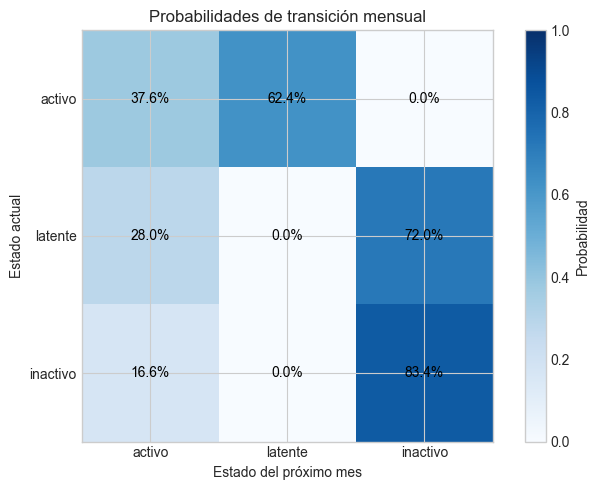

In [7]:
# El mapa de color revela la dinámica: la diagonal muestra persistencia y las celdas fuera de ella muestran reactivación o deterioro del vínculo.

figure, axis = plt.subplots(figsize=(7, 5))
image = axis.imshow(transition_matrix, vmin=0, vmax=1, cmap="Blues")
axis.set_xticks(range(len(state_order)), state_order)
axis.set_yticks(range(len(state_order)), state_order)
axis.set_xlabel("Estado del próximo mes")
axis.set_ylabel("Estado actual")
axis.set_title("Probabilidades de transición mensual")
for row in range(len(state_order)):
    for column in range(len(state_order)):
        value = transition_matrix.iloc[row, column]
        axis.text(column, row, f"{value:.1%}", ha="center", va="center", color="black")
figure.colorbar(image, ax=axis, label="Probabilidad")
figure.tight_layout()
plt.show()

In [8]:
# La regla de decisión del modelo toma el estado con mayor probabilidad; se contrasta con la línea base que conserva el estado actual sin aprender transiciones.

most_likely_next_state = transition_matrix.idxmax(axis=1).to_dict()
evaluation["markov_prediction"] = evaluation["state"].map(most_likely_next_state)
evaluation["persistence_prediction"] = evaluation["state"]
evaluation["markov_correct"] = evaluation["markov_prediction"].eq(evaluation["next_state"])
evaluation["persistence_correct"] = evaluation["persistence_prediction"].eq(evaluation["next_state"])

metrics = pd.DataFrame([
    {"model": "Persistencia", "accuracy": evaluation["persistence_correct"].mean()},
    {"model": "Transición de Markov", "accuracy": evaluation["markov_correct"].mean()},
]).round(3)

forecast_sample = evaluation[[
    "month", "customer_id", "state", "next_state", "markov_prediction", "persistence_prediction",
]].copy()
forecast_sample["month"] = forecast_sample["month"].astype(str)
forecast_sample.head(10), metrics

(         month  customer_id     state next_state markov_prediction  \
 17263  2011-08        12346  inactivo   inactivo          inactivo   
 17264  2011-08        12347    activo    latente           latente   
 17265  2011-08        12348  inactivo     activo          inactivo   
 17266  2011-08        12350  inactivo   inactivo          inactivo   
 17267  2011-08        12352  inactivo     activo          inactivo   
 17268  2011-08        12353  inactivo   inactivo          inactivo   
 17269  2011-08        12354  inactivo   inactivo          inactivo   
 17270  2011-08        12355  inactivo   inactivo          inactivo   
 17271  2011-08        12356  inactivo   inactivo          inactivo   
 17272  2011-08        12358   latente   inactivo          inactivo   
 
       persistence_prediction  
 17263               inactivo  
 17264                 activo  
 17265               inactivo  
 17266               inactivo  
 17267               inactivo  
 17268               inac

In [9]:
# La evidencia conserva la matriz, los pronósticos evaluados y los supuestos que separan una predicción de estados de una recomendación de retención.

figure.savefig(submission_dir / "transition_matrix.png", dpi=150, bbox_inches="tight")
transition_matrix.rename_axis("current_state").reset_index().to_csv(
    submission_dir / "transition_matrix.csv", index=False
)
forecast_sample.to_csv(submission_dir / "state_forecasts.csv", index=False)
metrics.to_csv(submission_dir / "model_metrics.csv", index=False)

assumptions = {
    "question": "What is the probability that a customer in each observed purchase state changes state next month?",
    "method": "First-order Markov transition matrix estimated from customer-month observations.",
    "states": {
        "activo": "Purchase in the current month.",
        "latente": "No purchase in the current month; purchase one month earlier.",
        "inactivo": "No purchase in the current or previous month.",
    },
    "baseline": "Persistence: predict that the next state equals the current state.",
    "limitations": [
        "State definitions are analytical choices based only on purchase recency.",
        "The transition estimates describe this retailer and observation window; they do not establish causes of customer behavior.",
        "Choosing an intervention, cost, or contact policy is a prescriptive question outside this activity.",
    ],
}
(submission_dir / "model_assumptions.json").write_text(
    json.dumps(assumptions, indent=2) + "\n"
)

metrics, transition_matrix.round(3)

(                  model  accuracy
 0          Persistencia     0.544
 1  Transición de Markov     0.696,
 next_state  activo  latente  inactivo
 state                                
 activo       0.376    0.624     0.000
 latente      0.280    0.000     0.720
 inactivo     0.166    0.000     0.834)